In [ ]:
import pandas as pd

In [ ]:
from sklearn.tree import DecisionTreeRegressor, export_text

# Load your training data
X = pd.read_csv('EVAL_7.csv')
y = pd.read_csv('target_7.csv')['target02']

# Train a very small tree
tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10)
tree.fit(X, y)

# Print the rules
print(export_text(tree, feature_names=list(X.columns)))

|--- feat_68 <= 5.22
|   |--- feat_238 <= -2.15
|   |   |--- feat_5 <= -2.07
|   |   |   |--- feat_139 <= 2.45
|   |   |   |   |--- value: [0.37]
|   |   |   |--- feat_139 >  2.45
|   |   |   |   |--- value: [-0.27]
|   |   |--- feat_5 >  -2.07
|   |   |   |--- feat_191 <= 2.82
|   |   |   |   |--- value: [0.06]
|   |   |   |--- feat_191 >  2.82
|   |   |   |   |--- value: [-0.26]
|   |--- feat_238 >  -2.15
|   |   |--- feat_44 <= 4.89
|   |   |   |--- feat_239 <= 1.87
|   |   |   |   |--- value: [-0.05]
|   |   |   |--- feat_239 >  1.87
|   |   |   |   |--- value: [0.03]
|   |   |--- feat_44 >  4.89
|   |   |   |--- feat_95 <= 2.70
|   |   |   |   |--- value: [0.36]
|   |   |   |--- feat_95 >  2.70
|   |   |   |   |--- value: [-0.22]
|--- feat_68 >  5.22
|   |--- feat_45 <= 2.29
|   |   |--- feat_173 <= 0.80
|   |   |   |--- feat_262 <= 0.52
|   |   |   |   |--- value: [0.54]
|   |   |   |--- feat_262 >  0.52
|   |   |   |   |--- value: [-0.02]
|   |   |--- feat_173 >  0.80
|   |   | 

In [2]:
# X.corr()
# y.c/orr()
y.describe()

NameError: name 'y' is not defined

Dataset Loaded: 10000 rows, 273 features


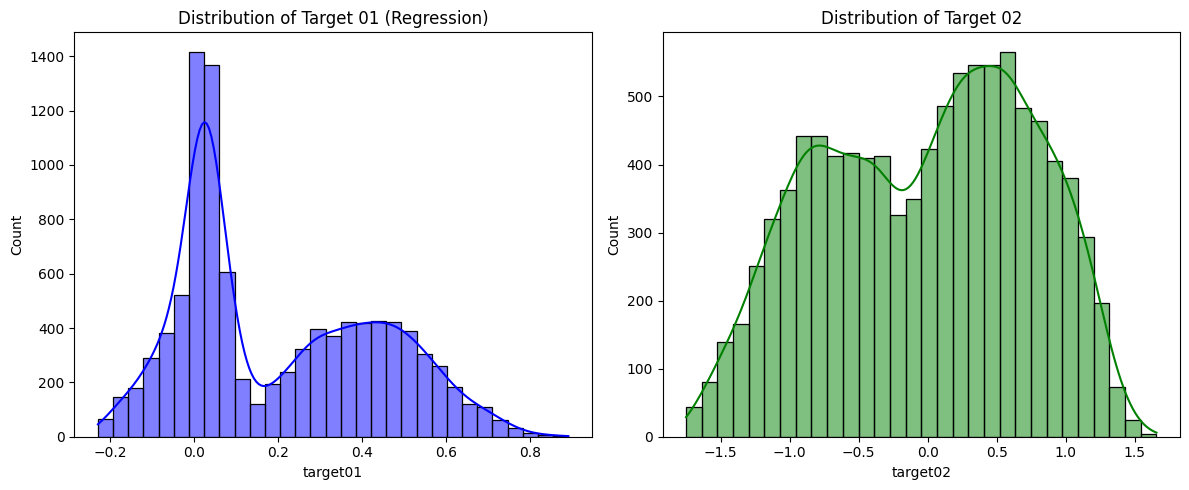

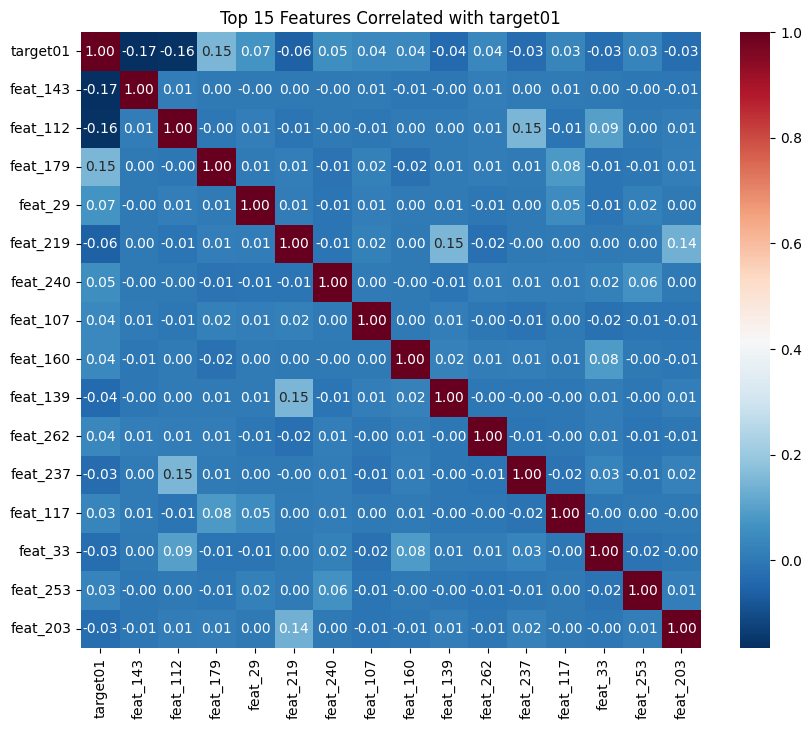

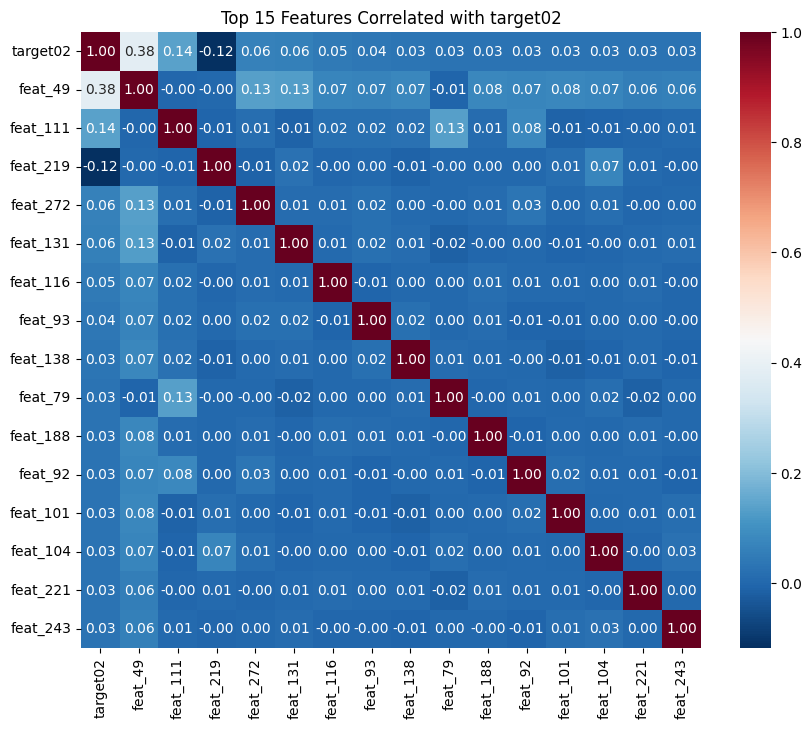

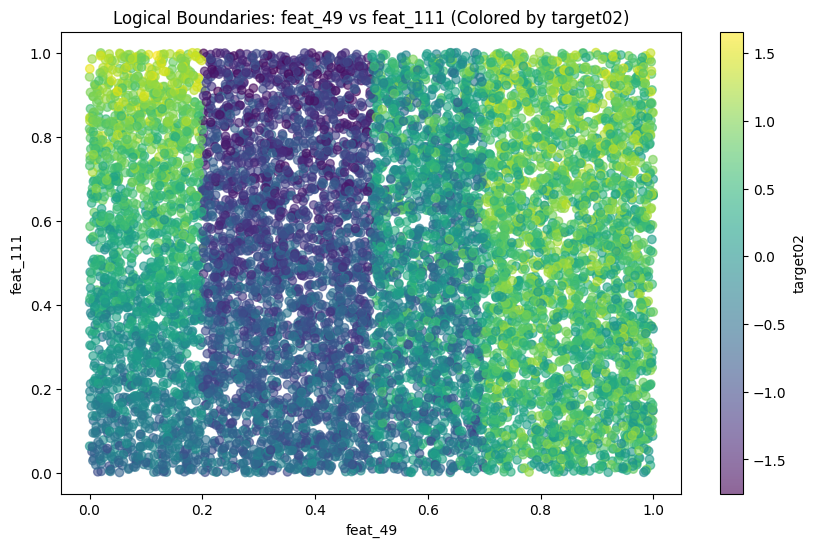

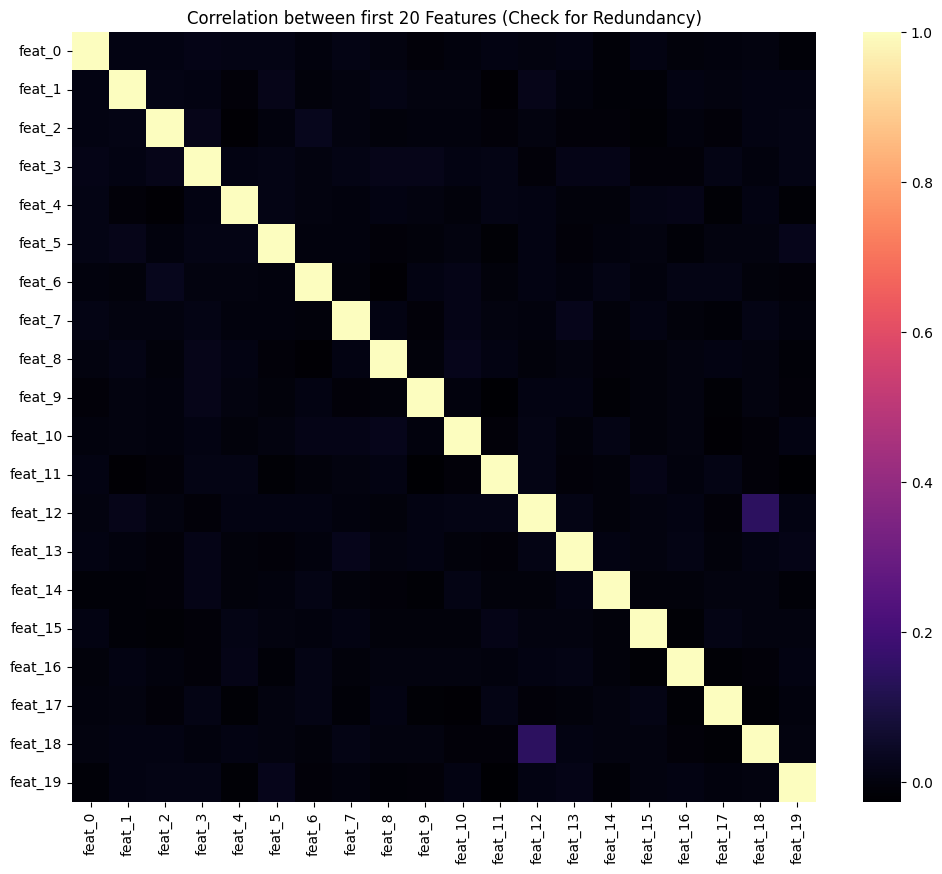

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA
# Ensure your filenames match your ID (7)
df_features = pd.read_csv('dataset_7.csv')  # Corrected from EVAL_7.csv
df_targets = pd.read_csv('target_7.csv')

# Merge for correlation analysis
df_full = pd.concat([df_features, df_targets], axis=1)

print(f"Dataset Loaded: {df_features.shape[0]} rows, {df_features.shape[1]} features")

# --- PART 1: TARGET ANALYSIS ---
def analyze_targets(targets):
    plt.figure(figsize=(12, 5))
    
    # Target 01 Distribution (Continuous)
    plt.subplot(1, 2, 1)
    sns.histplot(targets['target01'], kde=True, color='blue')
    plt.title('Distribution of Target 01 (Regression)')
    
    # Target 02 Distribution (Rule-based/Logic)
    plt.subplot(1, 2, 2)
    sns.histplot(targets['target02'], kde=True, color='green')
    plt.title('Distribution of Target 02')
    
    plt.tight_layout()
    plt.show()

analyze_targets(df_targets)

# --- PART 2: FEATURE-TARGET CORRELATION (The "Discovery" Phase) ---
def plot_top_correlations(df, target_col, n=15):
    # Calculate correlations
    corr_matrix = df.corr()
    # Get absolute correlations with the specific target
    top_corr = corr_matrix[target_col].abs().sort_values(ascending=False).head(n+1)
    top_features = top_corr.index
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[top_features].corr(), annot=True, cmap='RdBu_r', fmt=".2f")
    plt.title(f'Top {n} Features Correlated with {target_col}')
    plt.show()
    return top_features

# Run for both targets
top_feats_t1 = plot_top_correlations(df_full, 'target01')
top_feats_t2 = plot_top_correlations(df_full, 'target02')

# --- PART 3: RULE DISCOVERY VISUALS (For Target 02) ---
def rule_discovery_plot(df, top_features, target_col):
    # We take the top 2 features correlated with Target 02
    # and plot them to see if there is a geometric/logical boundary
    f1 = top_features[1] # [0] is the target itself
    f2 = top_features[2]
    
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(df[f1], df[f2], c=df[target_col], cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, label=target_col)
    plt.xlabel(f1)
    plt.ylabel(f2)
    plt.title(f'Logical Boundaries: {f1} vs {f2} (Colored by {target_col})')
    plt.show()

rule_discovery_plot(df_full, top_feats_t2, 'target02')

# --- PART 4: FEATURE REDUNDANCY (Feature vs Feature) ---
def internal_feature_correlation(df, n_sample=20):
    # Sampling the first 20 features just to see if the data is redundant/sparse
    subset = df.iloc[:, :n_sample]
    plt.figure(figsize=(12, 10))
    sns.heatmap(subset.corr(), cmap='magma')
    plt.title('Correlation between first 20 Features (Check for Redundancy)')
    plt.show()

internal_feature_correlation(df_features)

#AGain But now With Evaluation

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df_features, df_targets['target02'], test_size=0.3, random_state=42)

# Initialize and train the model
rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)


In [15]:
# Create a Series to see which features the model actually uses
importances = pd.Series(rf.feature_importances_, index=df_features.columns)
print(importances.sort_values(ascending=False).head(20))

feat_49     0.739182
feat_219    0.125691
feat_111    0.113879
feat_22     0.020819
feat_269    0.000089
feat_91     0.000076
feat_185    0.000033
feat_99     0.000033
feat_134    0.000028
feat_120    0.000023
feat_196    0.000019
feat_153    0.000017
feat_245    0.000013
feat_40     0.000012
feat_162    0.000011
feat_123    0.000011
feat_163    0.000011
feat_85     0.000009
feat_171    0.000009
feat_205    0.000006
dtype: float64


In [6]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse}")

r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2 ): {r2}")

from sklearn.metrics import explained_variance_score
evs = explained_variance_score(y_test, y_pred)
print(f"Explained Variance Score: {evs}")

import numpy as np
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")


Mean Absolute Error (MAE): 0.6500391346182796
Mean Squared Error (MSE): 0.5739096663927674
R-squared (R2 ): -0.001446051382654634
Explained Variance Score: -0.0012374794265916922
Mean Absolute Percentage Error (MAPE): 109.51338052775054%


In [7]:
from sklearn.feature_selection import mutual_info_regression

# Calculate MI for target02
mi_scores = mutual_info_regression(df_features, df_targets['target02'])
mi_series = pd.Series(mi_scores, index=df_features.columns)
print(mi_series.sort_values(ascending=False).head(10))

feat_154    0.023454
feat_83     0.019909
feat_33     0.019790
feat_169    0.018219
feat_156    0.017542
feat_134    0.017318
feat_206    0.016666
feat_121    0.016255
feat_208    0.015407
feat_50     0.014995
dtype: float64


|--- feat_111 <= 0.01
|   |--- feat_219 <= 0.87
|   |   |--- feat_111 <= 0.00
|   |   |   |--- value: [0.30]
|   |   |--- feat_111 >  0.00
|   |   |   |--- value: [-0.21]
|   |--- feat_219 >  0.87
|   |   |--- feat_49 <= 0.48
|   |   |   |--- value: [-1.33]
|   |   |--- feat_49 >  0.48
|   |   |   |--- value: [-0.12]
|--- feat_111 >  0.01
|   |--- feat_111 <= 0.39
|   |   |--- feat_49 <= 0.26
|   |   |   |--- value: [-0.06]
|   |   |--- feat_49 >  0.26
|   |   |   |--- value: [0.04]
|   |--- feat_111 >  0.39
|   |   |--- feat_111 <= 0.41
|   |   |   |--- value: [-0.15]
|   |   |--- feat_111 >  0.41
|   |   |   |--- value: [-0.03]



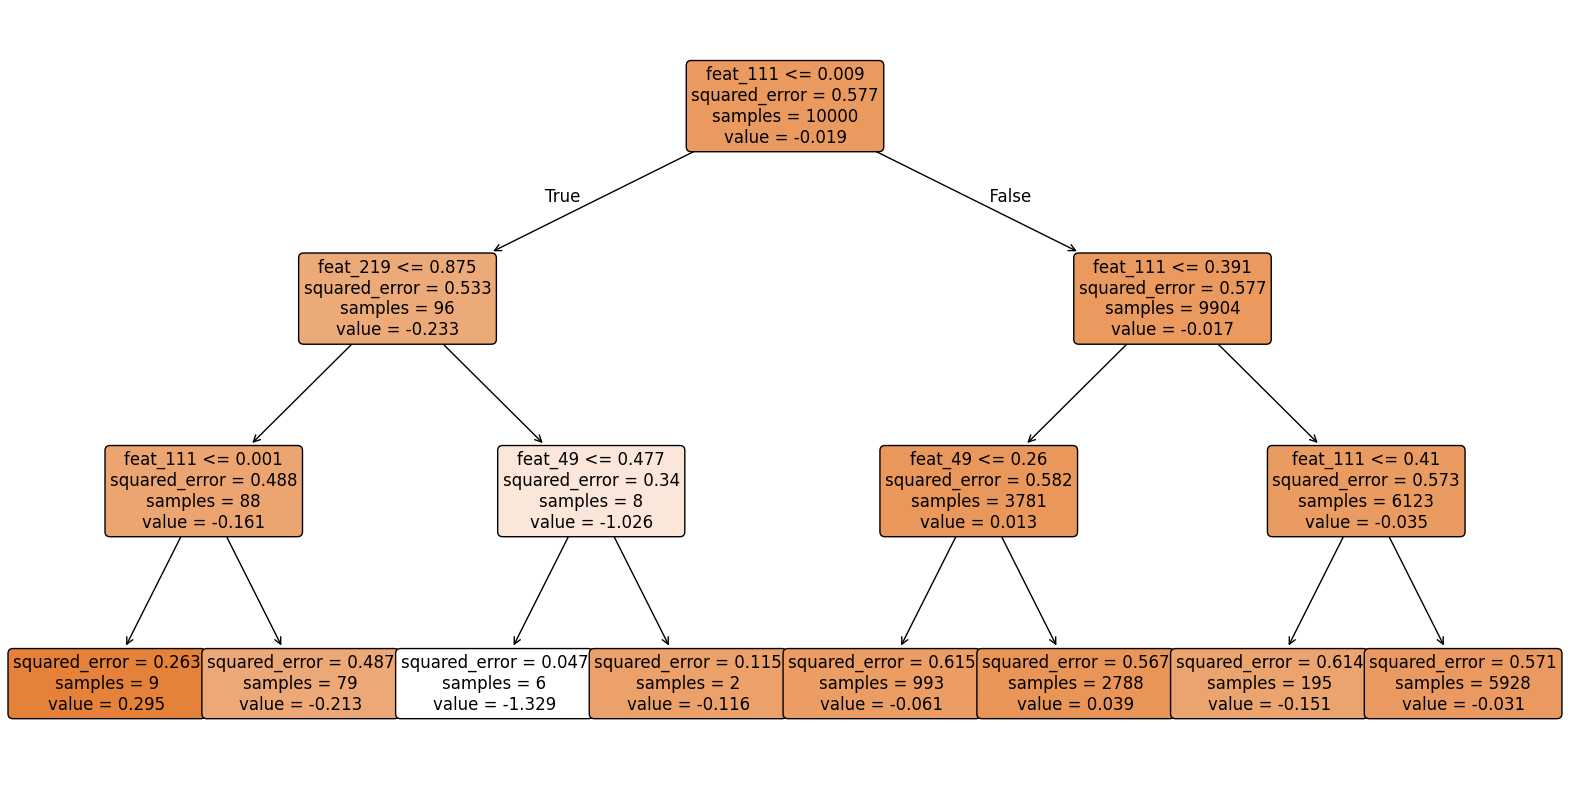

In [9]:
from sklearn.tree import DecisionTreeRegressor, export_text
import matplotlib.pyplot as plt
from sklearn import tree

# We only use the top 3 features found by your MI/RF analysis
top_features = ['feat_49', 'feat_219', 'feat_111']
X_subset = df_features[top_features]
y = df_targets['target02']

# Train a very shallow tree to find the "Simple Rules"
dt = DecisionTreeRegressor(max_depth=3) 
dt.fit(X_subset, y)

# Text version of the rules
print(export_text(dt, feature_names=top_features))

# Visual version (often easier to see the calculations)
plt.figure(figsize=(20,10))
tree.plot_tree(dt, feature_names=top_features, filled=True, rounded=True, fontsize=12)
plt.show()

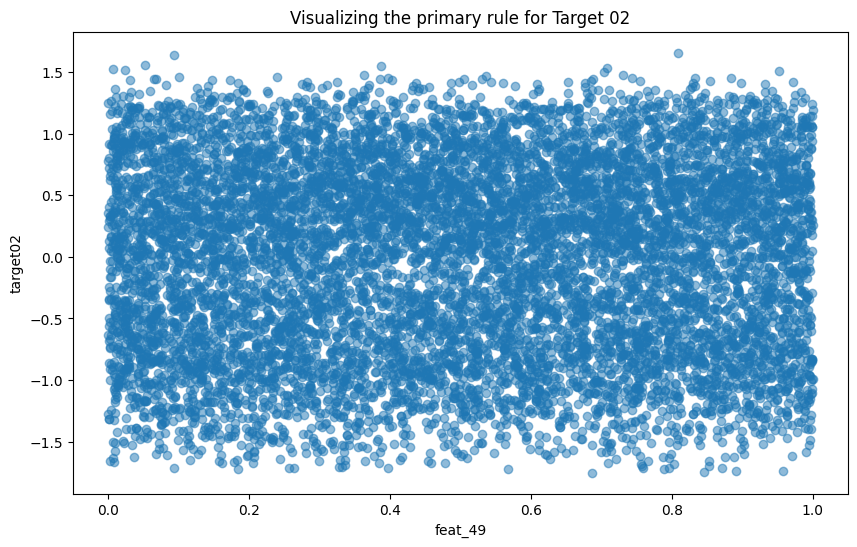

In [28]:
import matplotlib.pyplot as plt

# Plot the most important feature against the target
plt.figure(figsize=(10,6))
plt.scatter(df_features['feat_49'], df_targets['target02'], alpha=0.5)
plt.xlabel('feat_49')
plt.ylabel('target02')
plt.title('Visualizing the primary rule for Target 02')
plt.show()

In [29]:
# Calculate the IQR for each feature
Q1 = df_features.quantile(0.25)
Q3 = df_features.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = ((df_features < (Q1 - 1.5 * IQR)) | (df_features > (Q3 + 1.5 * IQR)))
print(df_features[outliers.any(axis=1)])


      feat_0  feat_1    feat_2    feat_3    feat_4    feat_5    feat_6  \
0       42.0    44.0  3.926807 -1.299520  0.282325 -0.862277  0.790855   
1       39.0    28.0 -0.381437 -0.361516  2.908935  2.179035  4.194874   
2       10.0    34.0  0.526166 -2.317522  1.974720  3.893945  0.249118   
3        7.0    24.0  1.880884 -1.524598  0.844415 -0.336772  1.290248   
4       26.0    14.0  1.108618 -3.251485  1.412500  1.367294 -2.643688   
...      ...     ...       ...       ...       ...       ...       ...   
9993    35.0    46.0 -1.511238 -3.014192 -1.350351  0.023838  0.195386   
9994    44.0     7.0  0.319898 -0.984946 -1.801670  0.111047  1.311275   
9996     8.0    46.0  2.384219  1.024982 -2.143056 -1.697373  1.109768   
9998    47.0    49.0  0.018394  0.650704 -2.977990  1.745730 -3.685923   
9999    32.0    28.0 -0.755839 -1.451998  0.295768  0.837169  0.511144   

        feat_7    feat_8    feat_9  ...  feat_263  feat_264  feat_265  \
0    -0.599205  1.817953  4.447058  ..

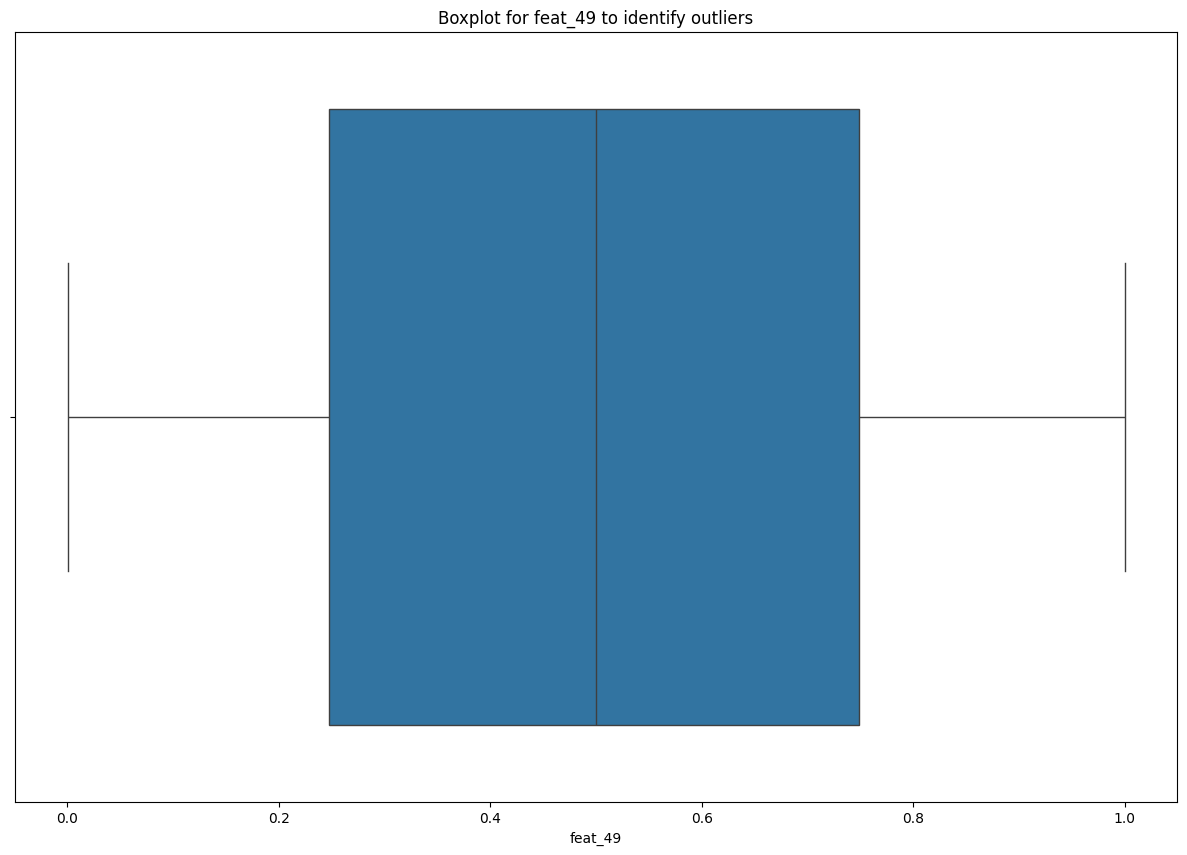

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize boxplots of each feature to spot potential outliers
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_features['feat_49'], orient='h')
plt.title('Boxplot for feat_49 to identify outliers')
plt.show()


## Dataset.csv vs EVAL.csv

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

def analyze_dataset_relationship(train_path, eval_path, target_feats):
    """
    Analyzes the relationship and distributional similarity between two datasets.
    """
    # 1. Load Datasets
    try:
        df_train = pd.read_csv(train_path)
        df_eval = pd.read_csv(eval_path)
        print(f"Loaded {train_path} ({df_train.shape}) and {eval_path} ({df_eval.shape})")
    except FileNotFoundError:
        return "Error: One or both files not found. Please ensure the CSV files are in the directory."

    # 2. Verify Features
    valid_feats = [f for f in target_feats if f in df_train.columns and f in df_eval.columns]
    missing_feats = list(set(target_feats) - set(valid_feats))
    
    if missing_feats:
        print(f"Warning: Features missing in one or both datasets: {missing_feats}")

    # 3. Descriptive Statistics Comparison
    stats_train = df_train[valid_feats].describe().T
    stats_eval = df_eval[valid_feats].describe().T
    
    # Calculate Percentage difference in Means
    comparison_df = pd.DataFrame({
        'Train_Mean': stats_train['mean'],
        'Eval_Mean': stats_eval['mean'],
        'Mean_Diff_%': np.abs((stats_train['mean'] - stats_eval['mean']) / stats_train['mean']) * 100,
        'Train_Std': stats_train['std'],
        'Eval_Std': stats_eval['std']
    })

    # 4. Correlation Analysis
    # Checking if the relationship BETWEEN target features is consistent
    corr_train = df_train[valid_feats].corr()
    corr_eval = df_eval[valid_feats].corr()
    corr_diff = (corr_train - corr_eval).abs()

    # 5. Distribution Similarity (Kolmogorov-Smirnov Test)
    # Null Hypothesis (H0): The two samples come from the same distribution.
    ks_results = []
    for feat in valid_feats:
        stat, p_val = ks_2samp(df_train[feat].dropna(), df_eval[feat].dropna())
        ks_results.append({
            'Feature': feat,
            'KS_Stat': stat,
            'P_Value': p_val,
            'Verdict': 'Same Distribution' if p_val > 0.05 else 'Different Distribution'
        })
    ks_df = pd.DataFrame(ks_results)

    # 6. Global Analysis (All Numeric Features)
    numeric_cols = df_train.select_dtypes(include=[np.number]).columns.intersection(df_eval.columns)
    global_ks_stats = []
    for col in numeric_cols:
        stat, _ = ks_2samp(df_train[col].dropna(), df_eval[col].dropna())
        global_ks_stats.append(stat)
    
    avg_global_ks = np.mean(global_ks_stats)

    # 7. Final Summary Report
    print("\n" + "="*50)
    print("DATASET RELATIONSHIP SUMMARY REPORT")
    print("="*50)
    
    print("\n[1] Descriptive Statistics for Target Features:")
    print(comparison_df.round(4))

    print("\n[2] Distribution Similarity (KS Test):")
    print(ks_df.to_string(index=False))

    print("\n[3] Correlation Stability (Mean Absolute Difference):")
    print(f"Average Correlation Shift: {corr_diff.values.mean():.4f}")

    print("\n[4] Global Comparison:")
    print(f"Number of common numeric features: {len(numeric_cols)}")
    print(f"Average KS Statistic across all features: {avg_global_ks:.4f}")

    print("\n" + "="*50)
    print("CONCLUSION")
    print("="*50)
    
    # Heuristic for relatedness:
    # 1. KS Stat < 0.1 indicates low drift.
    # 2. P-value > 0.05 suggests we cannot prove the distributions are different.
    significant_drift_count = (ks_df['P_Value'] < 0.05).sum()
    
    if avg_global_ks < 0.05 and significant_drift_count == 0:
        print("RESULT: Highly Related.")
        print("The datasets appear to originate from the same source/distribution.")
        print("A model trained on dataset_7.csv is highly suitable for EVAL_7.csv.")
    elif avg_global_ks < 0.15:
        print("RESULT: Related with Minor Drift.")
        print("The datasets share the same general structure, but minor variations exist.")
        print("The model should perform reasonably well, but validation is recommended.")
    else:
        print("RESULT: Likely Unrelated or Significant Covariate Shift.")
        print("Distributions differ significantly. A model trained on dataset_7.csv")
        print("may produce unreliable results on EVAL_7.csv without retraining or adaptation.")

# Execution
target_features = ['feat_49', 'feat_111', 'feat_219', 'feat_22', 'feat_64']
analyze_dataset_relationship('dataset_7.csv', 'EVAL_7.csv', target_features)

Loaded EVAL_7.csv ((10000, 273)) and EVAL_7.csv ((10000, 273))

DATASET RELATIONSHIP SUMMARY REPORT

[1] Descriptive Statistics for Target Features:
          Train_Mean  Eval_Mean  Mean_Diff_%  Train_Std  Eval_Std
feat_49       0.4987     0.4987          0.0     0.2905    0.2905
feat_111      0.5013     0.5013          0.0     0.2880    0.2880
feat_219      0.5038     0.5038          0.0     0.2871    0.2871
feat_22       0.4988     0.4988          0.0     0.2879    0.2879
feat_64       0.3035     0.3035          0.0     2.0221    2.0221

[2] Distribution Similarity (KS Test):
 Feature  KS_Stat  P_Value           Verdict
 feat_49      0.0      1.0 Same Distribution
feat_111      0.0      1.0 Same Distribution
feat_219      0.0      1.0 Same Distribution
 feat_22      0.0      1.0 Same Distribution
 feat_64      0.0      1.0 Same Distribution

[3] Correlation Stability (Mean Absolute Difference):
Average Correlation Shift: 0.0000

[4] Global Comparison:
Number of common numeric feature

In [32]:
import pandas as pd

# Assuming df_train and df_eval are already loaded
target_features = ['feat_49', 'feat_111', 'feat_219', 'feat_22', 'feat_64']

cross_dataset_correlations = {}

for feat in target_features:
    # We calculate the correlation between the series from Train and the series from Eval
    # Note: This assumes the rows are indexed or ordered the same way
    correlation = df_train[feat].corr(df_eval[feat])
    cross_dataset_correlations[feat] = correlation

# Convert to DataFrame for a clean output
cross_corr_df = pd.DataFrame.from_dict(cross_dataset_correlations, 
                                       orient='index', 
                                       columns=['Cross-Dataset Correlation'])

print("--- Correlation: Train Feature vs. Eval Feature ---")
print(cross_corr_df)


def plot_feature_overlap(df1, df2, features):
    plt.figure(figsize=(15, 10))
    for i, feat in enumerate(features, 1):
        plt.subplot(2, 3, i)
        sns.kdeplot(df1[feat], label='Train', fill=True, alpha=0.5)
        sns.kdeplot(df2[feat], label='Eval', fill=True, alpha=0.5)
        plt.title(f'Distribution Overlap: {feat}')
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_feature_overlap(df_train, df_eval, target_features)

NameError: name 'df_train' is not defined